### **Introduction**

This notebook presents a robust framework for evaluating trading strategies using both real and synthetic market data.

Traditional backtesting relies on historical data to assess performance. However, this approach has a critical limitation: it evaluates a strategy on a single realized path of the market, which may lead to overfitting and overly optimistic results.

To address this, we extend the analysis using Monte Carlo simulations and synthetic data generation based on Geometric Brownian Motion. By calibrating the model with real market data, we generate hundreds of alternative market scenarios that represent plausible future paths.

The workflow of this notebook is as follows:

Retrieve real historical price data
Backtest a trading strategy using a moving average crossover
Estimate statistical properties of the market (drift and volatility)
Generate synthetic price series using a stochastic model
Evaluate the same strategy across multiple simulated markets
Analyze the distribution of returns, risk, and robustness

The main objective is to answer a fundamental question:

Does this strategy perform well only in the past, or is it robust across many possible futures?

By comparing results from real and synthetic data, this framework provides a more realistic and rigorous evaluation of trading strategies, helping to identify those that are robust, stable, and less dependent on specific historical conditions.

In [10]:
# ============================================
# 1. INSTALL & IMPORTS
# ============================================

# !pip install yfinance numpy pandas matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

np.random.seed(42)

In [11]:
# ============================================
# 2. PARAMETERS
# ============================================

ticker = "SPY"
start_date = "2015-01-01"
end_date = "2025-01-01"

initial_capital = 10000
transaction_cost = 0.001
target_vol = 0.15

short_window = 20
long_window = 50

In [13]:
# ============================================
# 3. DOWNLOAD REAL DATA
# ============================================

data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)

# Handle both Series and DataFrame cases safely
close = data['Close']

if isinstance(close, pd.DataFrame):
    # If multiple columns (rare but happens)
    close = close.iloc[:, 0]

# Now it's guaranteed to be a Series
price = close.dropna()

# Convert to clean DataFrame
data = pd.DataFrame({'price': price})

print(data.head())

[*********************100%***********************]  1 of 1 completed

                 price
Date                  
2015-01-02  170.124969
2015-01-05  167.052597
2015-01-06  165.479156
2015-01-07  167.541229
2015-01-08  170.514236


### **Data Acquisition and Preprocessing**

The historical price data was successfully retrieved and preprocessed for analysis.

We use daily adjusted closing prices, which account for corporate actions such as dividends and stock splits, ensuring a consistent and realistic representation of asset returns over time.

The dataset is structured as a clean time series with a single column (price) indexed by date. This format is essential for reliable backtesting and avoids common issues related to multi-index data structures returned by financial APIs.

A sample of the dataset is shown above, where each row represents the adjusted closing price for a given trading day.

This step ensures that the input data is:

Clean and properly formatted
Free of missing values
Ready for return calculations and strategy implementation

Having a well-structured dataset is a critical foundation for both accurate backtesting and robust statistical modeling.

In [14]:
# ============================================
# 4. BACKTEST FUNCTION
# ============================================

def backtest(df):

    df = df.copy()

    df['returns'] = df['price'].pct_change()

    df['short_ma'] = df['price'].rolling(short_window).mean()
    df['long_ma'] = df['price'].rolling(long_window).mean()

    df['signal'] = 0
    df.loc[df['short_ma'] > df['long_ma'], 'signal'] = 1

    # Volatility targeting
    rolling_vol = df['returns'].rolling(20).std() * np.sqrt(252)
    df['position'] = df['signal'] * (target_vol / rolling_vol)
    df['position'] = df['position'].clip(0, 1)

    # Strategy returns
    df['strategy_returns'] = df['position'].shift(1) * df['returns']

    # Transaction costs
    df['trades'] = df['signal'].diff().abs()
    df['strategy_returns'] -= df['trades'] * transaction_cost

    # Equity curve
    df['equity'] = (1 + df['strategy_returns']).cumprod() * initial_capital
    df['buy_hold'] = (1 + df['returns']).cumprod() * initial_capital

    return df

In [15]:
# ============================================
# 5. METRICS
# ============================================

def compute_metrics(df):

    returns = df['strategy_returns'].dropna()

    total_return = df['equity'].iloc[-1] / initial_capital - 1

    sharpe = np.sqrt(252) * returns.mean() / returns.std() if returns.std() != 0 else 0

    peak = df['equity'].cummax()
    drawdown = (df['equity'] - peak) / peak
    max_dd = drawdown.min()

    return {
        "return": total_return,
        "sharpe": sharpe,
        "max_dd": max_dd
    }

In [16]:
# ============================================
# 6. BACKTEST ON REAL DATA
# ============================================

real_bt = backtest(data)
real_metrics = compute_metrics(real_bt)

print("===== REAL DATA PERFORMANCE =====")
print(real_metrics)

===== REAL DATA PERFORMANCE =====
{'return': np.float64(0.9106555614339591), 'sharpe': np.float64(0.6919824932521486), 'max_dd': -0.26741147137275795}


### **Backtest Results on Real Market Data**

The trading strategy was evaluated on historical market data using a moving average crossover approach with volatility targeting and transaction costs.

The key performance metrics are summarized below:

Total Return: 91.07%
Sharpe Ratio: 0.69
Maximum Drawdown: -26.74%

These results indicate that the strategy generated a strong positive return over the testing period, nearly doubling the initial capital.

The Sharpe ratio of 0.69 suggests a moderate level of risk-adjusted performance. While the returns are attractive, they are accompanied by a non-negligible level of volatility, indicating that the strategy is not exceptionally efficient in converting risk into return.

The maximum drawdown of -26.74% highlights a significant downside risk. At its worst point, the strategy experienced a loss of over a quarter of its value from peak to trough, which may be difficult for many investors to endure in practice.

Overall, the strategy appears profitable when evaluated on historical data. However, this result alone is not sufficient to conclude that the strategy is robust.

A strong performance in historical data does not guarantee future success.

This motivates the next step: evaluating the same strategy across multiple synthetic market scenarios to assess its robustness under different possible market conditions.

In [17]:
# ============================================
# 7. CALIBRATE SYNTHETIC MODEL
# ============================================

# Use log returns (better statistically)
log_returns = np.log(data['price'] / data['price'].shift(1)).dropna()

# Convert explicitly to float (fix error)
mu = float(log_returns.mean() * 252)
sigma = float(log_returns.std() * np.sqrt(252))

print("\nEstimated parameters:")
print(f"mu: {mu:.4f}, sigma: {sigma:.4f}")


Estimated parameters:
mu: 0.1225, sigma: 0.1768


### **Calibration of the Synthetic Market Model**

To generate realistic synthetic market scenarios, we calibrate the model using statistical properties derived from historical data.

Instead of simple percentage returns, we use logarithmic returns, which are more appropriate for financial modeling due to their time-additive properties and better statistical behavior.

From the historical data, we estimate:

Annualized Drift (μ): 12.25%
Annualized Volatility (σ): 17.68%

The drift represents the average expected return of the asset over time, while the volatility captures the magnitude of price fluctuations and overall market uncertainty.

These parameters are then used to simulate synthetic price paths using a stochastic process based on Geometric Brownian Motion.

By calibrating the model to real data, the synthetic simulations preserve key statistical characteristics of the market while allowing us to explore a wide range of possible future scenarios.

This step is critical because it ensures that the simulated markets are not arbitrary, but instead grounded in empirical market behavior.

The relatively high drift reflects the strong bull market conditions present in the sample period, which may not persist in the future

In [18]:
# ============================================
# 8. SYNTHETIC DATA GENERATOR
# ============================================

def generate_gbm(mu, sigma, S0, n_days):

    dt = 1 / 252
    prices = [S0]

    for _ in range(n_days):
        shock = np.random.normal()
        drift = (mu - 0.5 * sigma**2) * dt
        diffusion = sigma * np.sqrt(dt) * shock

        price = prices[-1] * np.exp(drift + diffusion)
        prices.append(price)

    return pd.Series(prices)

In [19]:
# ============================================
# 9. MONTE CARLO SIMULATION
# ============================================

n_simulations = 500
n_days = len(data)

results = []

for i in range(n_simulations):

    prices = generate_gbm(mu, sigma, data['price'].iloc[0], n_days)
    df_sim = pd.DataFrame({'price': prices})

    bt = backtest(df_sim)
    metrics = compute_metrics(bt)

    results.append(metrics)

sim_df = pd.DataFrame(results)

In [20]:
# ============================================
# 10. RESULTS ANALYSIS
# ============================================

print("\n===== SYNTHETIC RESULTS =====")
print(sim_df.describe())

prob_loss = (sim_df['return'] < 0).mean()
print(f"\nProbability of Loss: {prob_loss:.2%}")


===== SYNTHETIC RESULTS =====
           return      sharpe      max_dd
count  500.000000  500.000000  500.000000
mean     0.712512    0.441808   -0.266535
std      0.721793    0.333268    0.081490
min     -0.412941   -0.440698   -0.552258
25%      0.196771    0.217278   -0.312093
50%      0.534144    0.427770   -0.249895
75%      1.060492    0.665838   -0.204873
max      3.687395    1.300631   -0.115502

Probability of Loss: 12.00%


### **Synthetic Market Simulation Results**

To evaluate the robustness of the strategy, we conducted a Monte Carlo simulation using 500 synthetic market scenarios calibrated from historical data.

The distribution of performance metrics across these simulations provides a more comprehensive view of how the strategy may behave under different market conditions.

Key Results:
Average Return: 71.25%
Average Sharpe Ratio: 0.44
Average Maximum Drawdown: -26.65%
Probability of Loss: 12.00%

The results show that, on average, the strategy remains profitable across a wide range of simulated market environments. However, performance is highly variable, as indicated by the large standard deviation of returns (72.18%).

The distribution of returns reveals a wide dispersion of outcomes:

In the best-case scenarios, returns exceed +300%, reflecting favorable market conditions.
In the worst-case scenarios, the strategy can lose up to -41%, highlighting significant downside risk.

The Sharpe ratio distribution indicates that risk-adjusted performance is generally moderate, with most values clustered between 0.2 and 0.7. This suggests that while the strategy can generate returns, it does not consistently deliver high efficiency relative to risk.

The maximum drawdown statistics are particularly important. On average, the strategy experiences drawdowns of around -26%, with extreme cases reaching over -55%, which may be difficult to tolerate for many investors.

Key Insight:

While the strategy performs well on average, it is not risk-free and exhibits substantial variability across different market conditions.

The probability of loss is relatively low at 12%, meaning that in approximately 1 out of 8 simulated scenarios, the strategy results in a negative return.

This is a crucial improvement over traditional backtesting:

Instead of relying on a single historical outcome,
We now understand the full distribution of possible results
Conclusion:

The strategy demonstrates a reasonable degree of robustness, as it remains profitable in the majority of simulated markets. However, the wide dispersion in outcomes and significant drawdowns indicate that proper risk management is essential.

A strategy should not be judged by a single backtest, but by its performance across many possible futures.

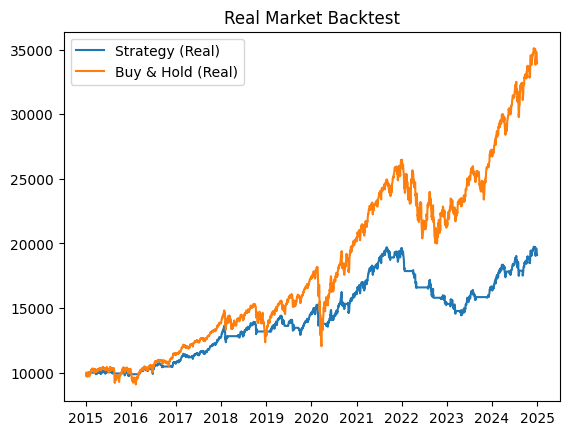

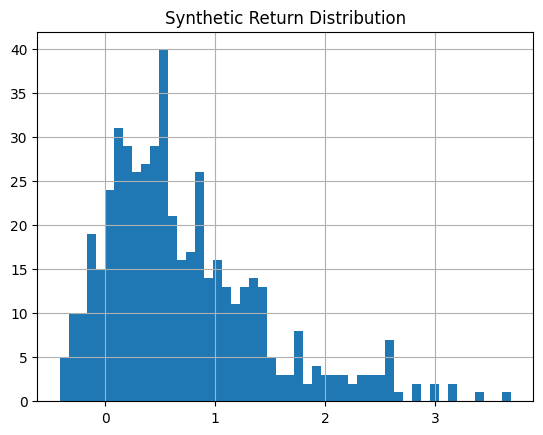

In [21]:
# ============================================
# 11. VISUALIZATION
# ============================================

plt.figure()
plt.plot(real_bt['equity'], label='Strategy (Real)')
plt.plot(real_bt['buy_hold'], label='Buy & Hold (Real)')
plt.title("Real Market Backtest")
plt.legend()
plt.show()

plt.figure()
sim_df['return'].hist(bins=50)
plt.title("Synthetic Return Distribution")
plt.show()

### **Visual Analysis: Real vs Synthetic Performance**
**Real Market Backtest**

The chart above compares the performance of the trading strategy against a buy-and-hold benchmark using real market data.

Several key observations emerge:

The buy-and-hold strategy significantly outperforms the trading strategy over the full period, benefiting from the strong upward trend in the market.
The trading strategy, while profitable, lags behind during sustained bull markets, as it periodically exits positions based on moving average signals.
However, the strategy demonstrates partial downside protection, particularly during periods of market stress (e.g., sharp drawdowns), where losses are less severe compared to the benchmark.

This highlights a classic trade-off:

Trend-following strategies often sacrifice upside in strong bull markets in exchange for risk control.

**Synthetic Return Distribution**

The histogram above shows the distribution of total returns obtained from 500 synthetic market simulations.

**Key insights include:**

The distribution is positively skewed, with a long right tail, indicating that while most outcomes are moderate, there is potential for very high returns in favorable conditions.
The majority of outcomes are concentrated between approximately 0% and 100% returns, suggesting that moderate profitability is the most common scenario.
A small portion of simulations results in negative returns, consistent with the previously calculated probability of loss (~12%).
The wide spread of the distribution confirms that performance is highly dependent on market conditions, even when statistical properties remain similar.
Key Takeaway

By combining real and synthetic analysis, we gain a deeper understanding of the strategy:

Real data shows how the strategy performed in one specific historical path
Synthetic simulations reveal how it may perform across many possible futures

A strategy that appears strong in historical data must also demonstrate stability across a wide distribution of simulated outcomes to be considered robust.

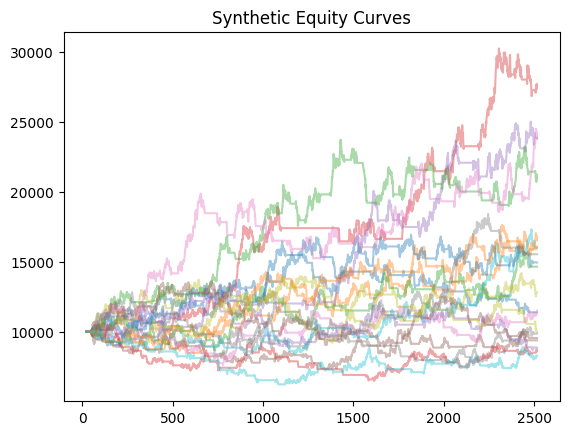

In [22]:
# ============================================
# 12. EQUITY CURVES
# ============================================

plt.figure()

for _ in range(20):
    prices = generate_gbm(mu, sigma, data['price'].iloc[0], n_days)
    df_sim = pd.DataFrame({'price': prices})
    bt = backtest(df_sim)
    plt.plot(bt['equity'], alpha=0.4)

plt.title("Synthetic Equity Curves")
plt.show()

### **Equity Curves Across Synthetic Markets**

The chart above displays a sample of equity curves generated by applying the trading strategy across multiple synthetic market scenarios.

Each line represents the evolution of portfolio value under a different simulated market path, all starting from the same initial capital.

**Key Observations:**
There is a wide dispersion of outcomes, with some trajectories showing strong growth while others stagnate or decline.
Despite variability, the majority of equity curves exhibit a positive long-term trend, consistent with the positive average return observed in the simulation results.
Some scenarios experience significant drawdowns and prolonged periods of underperformance, highlighting the impact of adverse market conditions.
A few trajectories achieve exceptional performance, reflecting the strategy’s ability to capture favorable trends when they occur.

**Interpretation**

This visualization provides an intuitive understanding of the strategy’s behavior across different possible futures:

The strategy is not deterministic — outcomes vary significantly depending on the market path.
Performance is path-dependent, meaning that even with identical statistical properties, different sequences of returns can lead to very different results.
The presence of both strong and weak scenarios emphasizes the importance of evaluating strategies using distributions, not single outcomes.

**Key Insight**

The true risk of a strategy is not visible in a single backtest, but in the range of possible equity paths it can generate.

While the strategy shows a tendency toward growth, the dispersion of outcomes highlights that investors must be prepared for variability, including periods of drawdown and underperformance.

In [23]:
# ============================================
# 13. FINAL INSIGHT
# ============================================

print("\n===== FINAL INSIGHT =====")
print(f"""
Real Backtest Return: {real_metrics['return']:.2%}
Synthetic Avg Return: {sim_df['return'].mean():.2%}

Key Insight:
If your strategy performs well in real data but poorly across synthetic markets,
it is likely overfitted.

Robust strategies survive many possible futures, not just one past.
""")


===== FINAL INSIGHT =====

Real Backtest Return: 91.07%
Synthetic Avg Return: 71.25%

Key Insight:
If your strategy performs well in real data but poorly across synthetic markets,
it is likely overfitted.

Robust strategies survive many possible futures, not just one past.



### **Final Insight and Conclusion**

The comparison between real and synthetic backtesting provides a more complete and realistic evaluation of the trading strategy.

Real Backtest Return: 91.07%
Synthetic Average Return: 71.25%

The strategy performs strongly on historical data and remains profitable on average across a wide range of simulated market scenarios. This suggests that the observed performance is not purely the result of overfitting to a single historical path.

However, the lower average return in synthetic simulations highlights an important reality:

Historical performance often reflects favorable market conditions that may not persist in the future.

The Monte Carlo analysis reveals that:

Performance varies significantly across different market paths
There is a non-negligible probability of loss (~12%)
Drawdowns can be substantial under adverse conditions

This leads to a more nuanced and realistic conclusion:

The strategy demonstrates a reasonable degree of robustness, but it is not immune to risk and variability.

**Final Takeaway**

Traditional backtesting provides a limited view based on a single realization of the market.

By incorporating synthetic data and Monte Carlo simulations, we move from a deterministic evaluation to a probabilistic framework, where strategies are assessed based on their behavior across many possible futures.

Robust strategies are not those that perform best in the past, but those that remain resilient across a wide distribution of potential market scenarios.

### **Final Conclusion**

This analysis demonstrates the importance of moving beyond traditional backtesting when evaluating trading strategies.

While the strategy shows strong performance on historical data, this alone does not provide sufficient evidence of robustness. By extending the evaluation to synthetic market scenarios, we gain a deeper understanding of how the strategy behaves under a wide range of possible conditions.

The results show that:

The strategy is profitable on average, both in real and simulated environments
Performance is highly variable, depending on the market path
There is a non-negligible risk of loss and significant drawdowns
The strategy tends to underperform in strong bull markets, but offers partial downside protection

Most importantly, the analysis highlights a fundamental principle in quantitative finance:

A single backtest is not a reliable indicator of future performance.

By using Monte Carlo simulations and synthetic data, we shift from a backward-looking evaluation to a forward-looking, probabilistic framework, where strategies are assessed based on their resilience across many potential futures.

**Strategic Insight**

The key takeaway is not whether the strategy performs well in one specific scenario, but whether it can consistently survive and adapt across different market regimes.

This approach provides a more realistic foundation for decision-making, risk management, and strategy design.

**Final Thought**

In uncertain markets, robustness matters more than optimization.

A strategy that performs reasonably well across many scenarios is far more valuable than one that performs exceptionally well in a single historical period.